# How GNN Models See Crystal Structures

Full pipeline from **crystal structure → graph → model input**

1. What a crystal structure actually *is* (lattice + atoms + periodicity)
2. How `pymatgen.Structure` stores it
3. How MatGL's `Structure2Graph` converts it to a graph
4. What nodes, edges, and features look like to the GNN
5. Why this representation captures the physics

In [1]:
from __future__ import annotations

import warnings
warnings.simplefilter("ignore")

import matplotlib.pyplot as plt
import numpy as np
import torch
from pymatgen.core import Lattice, Structure

from matgl.ext._pymatgen_pyg import Structure2Graph, get_element_list
from matgl.layers import BondExpansion

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 1. What is a crystal structure?

A crystal is a **repeating arrangement of atoms** in 3D space. It is fully described by:

| Component | Meaning |
|---|---|
| **Lattice** | A 3×3 matrix of vectors **a**, **b**, **c** that define the repeating "box" |
| **Species** | Which element sits at each site (Si, O, Ti, ...) |
| **Fractional coordinates** | Where each atom sits *inside* the box, as fractions of **a**, **b**, **c** (values 0–1) |

The box repeats infinitely in all directions. Every atom at position **r** also appears at **r** + n₁**a** + n₂**b** + n₃**c** for all integers n₁, n₂, n₃. This is **periodicity**.

Let's build a few real materials:

In [2]:
# --- Build three example structures ---

# Silicon: diamond cubic, the most common semiconductor
si = Structure.from_spacegroup(
    "Fd-3m", Lattice.cubic(5.431), ["Si"], [[0.0, 0.0, 0.0]]
)

# CsCl: simple cubic with 2 atoms
cscl = Structure.from_spacegroup(
    "Pm-3m", Lattice.cubic(4.123), ["Cs", "Cl"], [[0, 0, 0], [0.5, 0.5, 0.5]]
)

# SrTiO3: perovskite — a classic high-permittivity material
srtio3 = Structure.from_spacegroup(
    "Pm-3m",
    Lattice.cubic(3.905),
    ["Sr", "Ti", "O"],
    [[0, 0, 0], [0.5, 0.5, 0.5], [0.5, 0.5, 0]],
)

structures = {"Si": si, "CsCl": cscl, "SrTiO₃": srtio3}

for name, s in structures.items():
    print(f"{'─'*50}")
    print(f"  {name}  ({s.formula})")
    print(f"  Lattice params : a={s.lattice.a:.3f} Å, α={s.lattice.alpha:.0f}°")
    print(f"  Volume         : {s.volume:.2f} ų")
    print(f"  Sites          : {s.num_sites}")
    print(f"  Elements       : {s.symbol_set}")

──────────────────────────────────────────────────
  Si  (Si8)
  Lattice params : a=5.431 Å, α=90°
  Volume         : 160.19 ų
  Sites          : 8
  Elements       : ('Si',)
──────────────────────────────────────────────────
  CsCl  (Cs1 Cl1)
  Lattice params : a=4.123 Å, α=90°
  Volume         : 70.09 ų
  Sites          : 2
  Elements       : ('Cl', 'Cs')
──────────────────────────────────────────────────
  SrTiO₃  (Sr1 Ti1 O3)
  Lattice params : a=3.905 Å, α=90°
  Volume         : 59.55 ų
  Sites          : 5
  Elements       : ('O', 'Sr', 'Ti')


## 2. Inspecting a Structure object

Let's take SrTiO₃ (a perovskite with very high permittivity ~300) and look at every piece of data the model will eventually consume:

In [3]:
s = srtio3

print("=== Lattice ===")
print(f"  Matrix (rows = a, b, c vectors in Å):\n{s.lattice.matrix}\n")
print(f"  a = {s.lattice.a:.4f} Å")
print(f"  b = {s.lattice.b:.4f} Å")
print(f"  c = {s.lattice.c:.4f} Å")
print(f"  α = {s.lattice.alpha:.1f}°  β = {s.lattice.beta:.1f}°  γ = {s.lattice.gamma:.1f}°")
print(f"  Volume = {s.lattice.volume:.3f} ų\n")

print("=== Sites (atoms in the unit cell) ===")
for i, site in enumerate(s.sites):
    print(
        f"  [{i}] {site.species_string:>3s}  "
        f"frac=({site.frac_coords[0]:.2f}, {site.frac_coords[1]:.2f}, {site.frac_coords[2]:.2f})  "
        f"cart=({site.coords[0]:.3f}, {site.coords[1]:.3f}, {site.coords[2]:.3f}) Å"
    )

print(f"\n=== NumPy arrays (what code actually uses) ===")
print(f"  frac_coords shape: {s.frac_coords.shape}")
print(f"  cart_coords shape: {s.cart_coords.shape}")

=== Lattice ===
  Matrix (rows = a, b, c vectors in Å):
[[3.905 0.    0.   ]
 [0.    3.905 0.   ]
 [0.    0.    3.905]]

  a = 3.9050 Å
  b = 3.9050 Å
  c = 3.9050 Å
  α = 90.0°  β = 90.0°  γ = 90.0°
  Volume = 59.547 ų

=== Sites (atoms in the unit cell) ===
  [0]  Sr  frac=(0.00, 0.00, 0.00)  cart=(0.000, 0.000, 0.000) Å
  [1]  Ti  frac=(0.50, 0.50, 0.50)  cart=(1.952, 1.952, 1.952) Å
  [2]   O  frac=(0.50, 0.00, 0.50)  cart=(1.952, 0.000, 1.952) Å
  [3]   O  frac=(0.00, 0.50, 0.50)  cart=(0.000, 1.952, 1.952) Å
  [4]   O  frac=(0.50, 0.50, 0.00)  cart=(1.952, 1.952, 0.000) Å

=== NumPy arrays (what code actually uses) ===
  frac_coords shape: (5, 3)
  cart_coords shape: (5, 3)


## 3. Neighbors — the physics the model needs to capture

Atoms interact with nearby atoms. In a crystal, "nearby" includes atoms in neighbouring copies of the unit cell (periodic images). pymatgen handles this automatically:

In [4]:
CUTOFF = 5.0  # Å — same as the model's graph cutoff

print(f"Neighbors of each site within {CUTOFF} Å:\n")
all_neighbors = s.get_all_neighbors(r=CUTOFF)

for i, (site, nbrs) in enumerate(zip(s.sites, all_neighbors)):
    nbrs_sorted = sorted(nbrs, key=lambda n: n.nn_distance)
    print(f"  Site {i} ({site.species_string}):")
    for nn in nbrs_sorted[:6]:  # show first 6
        print(f"    → {nn.species_string}  d = {nn.nn_distance:.3f} Å  image = {nn.image}")
    if len(nbrs_sorted) > 6:
        print(f"    ... ({len(nbrs_sorted)} total neighbors)")
    print()

Neighbors of each site within 5.0 Å:

  Site 0 (Sr):
    → O  d = 2.761 Å  image = (np.float64(0.0), np.float64(0.0), np.float64(0.0))
    → O  d = 2.761 Å  image = (np.float64(0.0), np.float64(0.0), np.float64(0.0))
    → O  d = 2.761 Å  image = (np.float64(0.0), np.float64(0.0), np.float64(0.0))
    → O  d = 2.761 Å  image = (np.float64(-1.0), np.float64(0.0), np.float64(0.0))
    → O  d = 2.761 Å  image = (np.float64(-1.0), np.float64(0.0), np.float64(0.0))
    → O  d = 2.761 Å  image = (np.float64(0.0), np.float64(-1.0), np.float64(0.0))
    ... (50 total neighbors)

  Site 1 (Ti):
    → O  d = 1.952 Å  image = (np.float64(1.0), np.float64(0.0), np.float64(0.0))
    → O  d = 1.952 Å  image = (np.float64(0.0), np.float64(1.0), np.float64(0.0))
    → O  d = 1.952 Å  image = (np.float64(0.0), np.float64(0.0), np.float64(1.0))
    → O  d = 1.952 Å  image = (np.float64(0.0), np.float64(0.0), np.float64(0.0))
    → O  d = 1.952 Å  image = (np.float64(0.0), np.float64(0.0), np.float64(0.0

**Key insight:** The `image` tuple (e.g. `(1, 0, -1)`) tells you this neighbor comes from the unit cell shifted by 1×**a** + 0×**b** − 1×**c**. The model must account for periodic images — it doesn't just look at atoms in a single box.

## 4. Structure → Graph: what MatGL does

`Structure2Graph` converts a pymatgen Structure into a PyTorch Geometric `Data` object:
- **Nodes** = atoms (one per site in the unit cell)
- **Edges** = pairs of atoms within the cutoff distance, *including periodic images*
- **`node_type`** = integer index for each element (used to look up a learned embedding)
- **`pbc_offset`** = the periodic image shift for each edge (so the model knows the bond crosses a cell boundary)
- **`frac_coords`** = fractional coordinates of each atom

In [5]:
all_structs = list(structures.values())
element_types = get_element_list(all_structs)
print(f"Element vocabulary (sorted): {element_types}\n")

converter = Structure2Graph(element_types=element_types, cutoff=CUTOFF)

for name, struct in structures.items():
    graph, lattice, state = converter.get_graph(struct)
    print(f"{'─'*55}")
    print(f"  {name}  →  {graph}")
    print(f"  node_type  : {graph.node_type.tolist()}  (element indices)")
    print(f"  edge_index : shape {list(graph.edge_index.shape)}  ({graph.edge_index.shape[1]} directed edges)")
    print(f"  pbc_offset : shape {list(graph.pbc_offset.shape)}")
    print(f"  frac_coords: shape {list(graph.frac_coords.shape)}")
    print(f"  lattice    : shape {list(lattice.shape)}")
    print()

Element vocabulary (sorted): ('O', 'Si', 'Cl', 'Ti', 'Sr', 'Cs')

───────────────────────────────────────────────────────
  Si  →  Data(edge_index=[2, 224], num_nodes=8, pbc_offset=[224, 3], node_type=[8], frac_coords=[8, 3])
  node_type  : [1, 1, 1, 1, 1, 1, 1, 1]  (element indices)
  edge_index : shape [2, 224]  (224 directed edges)
  pbc_offset : shape [224, 3]
  frac_coords: shape [8, 3]
  lattice    : shape [1, 3, 3]

───────────────────────────────────────────────────────
  CsCl  →  Data(edge_index=[2, 28], num_nodes=2, pbc_offset=[28, 3], node_type=[2], frac_coords=[2, 3])
  node_type  : [5, 2]  (element indices)
  edge_index : shape [2, 28]  (28 directed edges)
  pbc_offset : shape [28, 3]
  frac_coords: shape [2, 3]
  lattice    : shape [1, 3, 3]

───────────────────────────────────────────────────────
  SrTiO₃  →  Data(edge_index=[2, 250], num_nodes=5, pbc_offset=[250, 3], node_type=[5], frac_coords=[5, 3])
  node_type  : [4, 3, 0, 0, 0]  (element indices)
  edge_index : shap

## 5. Visualising the crystal graph

Let's plot the graph for SrTiO₃. Each node is coloured by element, and edges connect atoms that are within the cutoff. Note how 5 atoms generate many more edges — those are bonds to periodic images.

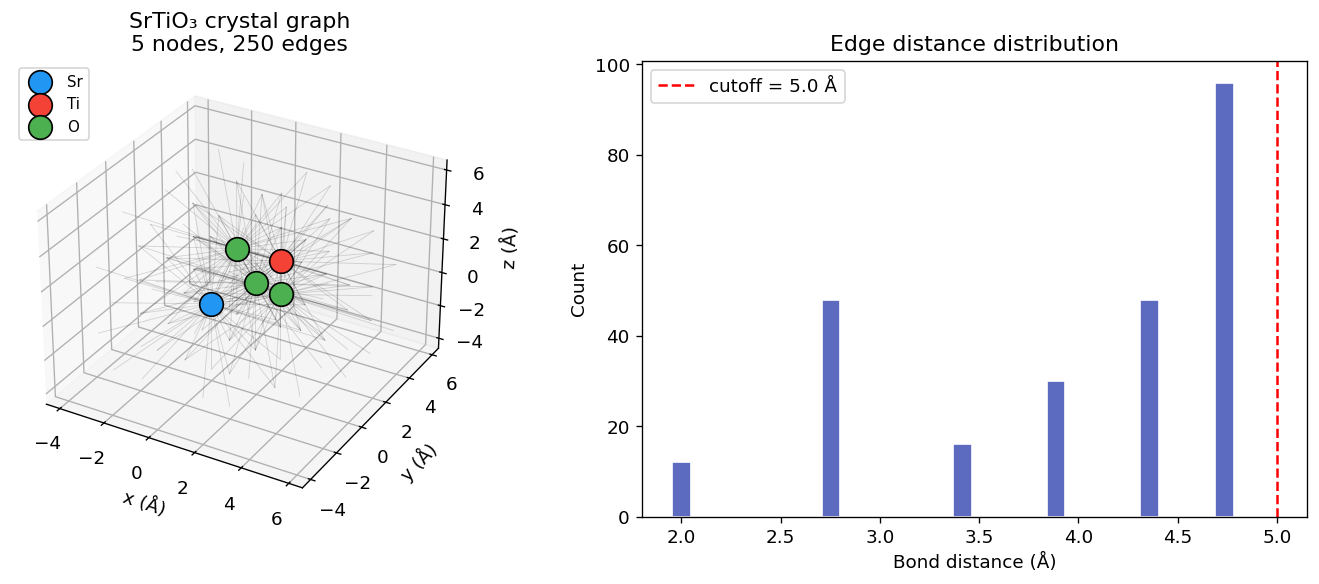

In [6]:
graph_sto, lattice_sto, _ = converter.get_graph(srtio3)
edge_index = graph_sto.edge_index.numpy()  # (2, num_edges)
pbc = graph_sto.pbc_offset.numpy()
frac = graph_sto.frac_coords.numpy()
cart = srtio3.cart_coords

# Reconstruct neighbour Cartesian positions using pbc_offset
lat_matrix = srtio3.lattice.matrix  # (3, 3)
src_idx, dst_idx = edge_index[0], edge_index[1]
dst_real = cart[dst_idx] + pbc @ lat_matrix  # actual position of the image atom

# --- Plot ---
fig = plt.figure(figsize=(12, 5))

# (a) 3D atom positions + edges
ax1 = fig.add_subplot(121, projection="3d")
colors_map = {"Sr": "#2196F3", "Ti": "#F44336", "O": "#4CAF50", "Si": "#9C27B0", "Cs": "#FF9800", "Cl": "#00BCD4"}
for i, site in enumerate(srtio3.sites):
    c = colors_map.get(site.species_string, "gray")
    ax1.scatter(*cart[i], s=200, c=c, edgecolors="k", zorder=5, label=site.species_string if i < 5 else "")

for e in range(len(src_idx)):
    ax1.plot(
        [cart[src_idx[e], 0], dst_real[e, 0]],
        [cart[src_idx[e], 1], dst_real[e, 1]],
        [cart[src_idx[e], 2], dst_real[e, 2]],
        "k-", alpha=0.15, linewidth=0.5,
    )

ax1.set_xlabel("x (Å)")
ax1.set_ylabel("y (Å)")
ax1.set_zlabel("z (Å)")
ax1.set_title(f"SrTiO₃ crystal graph\n{srtio3.num_sites} nodes, {edge_index.shape[1]} edges")
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc="upper left", fontsize=9)

# (b) Edge distance histogram
src_cart = cart[src_idx]
distances = np.linalg.norm(dst_real - src_cart, axis=1)

ax2 = fig.add_subplot(122)
ax2.hist(distances, bins=30, edgecolor="white", color="#5C6BC0")
ax2.axvline(CUTOFF, color="red", linestyle="--", label=f"cutoff = {CUTOFF} Å")
ax2.set_xlabel("Bond distance (Å)")
ax2.set_ylabel("Count")
ax2.set_title("Edge distance distribution")
ax2.legend()

plt.tight_layout()
plt.show()

## 6. Edge features: Radial Basis Function expansion

The model doesn't use raw distances directly. Instead, each distance is **expanded** into a vector of radial basis functions (RBFs). This is analogous to positional encoding in transformers — it gives the model a richer, smoother representation of distance.

Two common choices:
- **Gaussian RBF**: a set of Gaussian bumps centred at evenly spaced distances
- **Spherical Bessel**: physics-motivated basis functions from quantum mechanics

Below we visualise both:

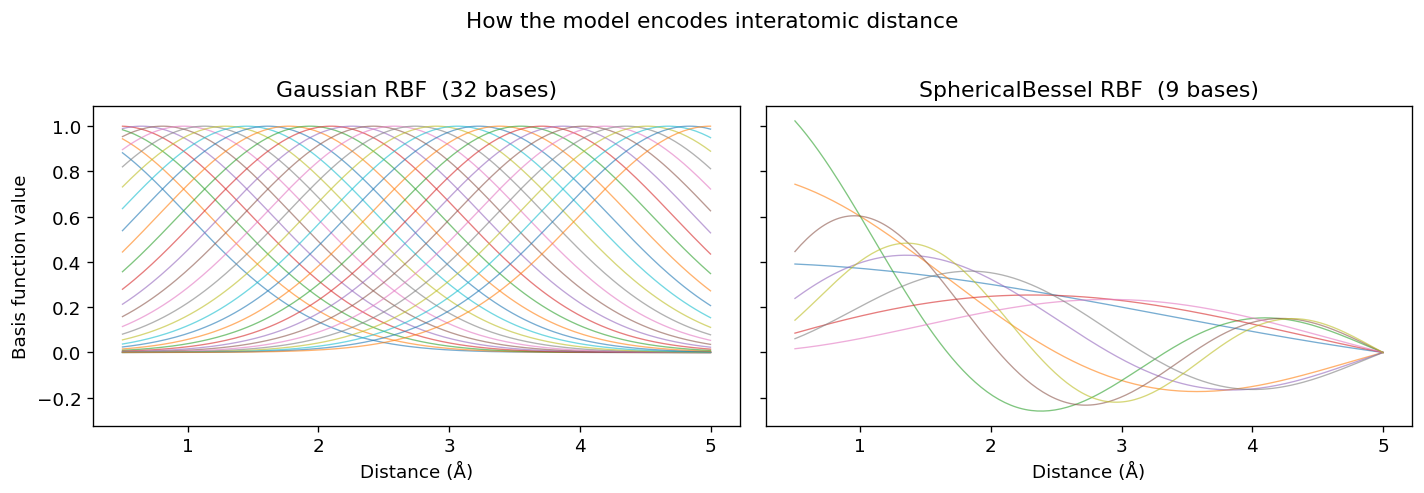

In [7]:
d_range = torch.linspace(0.5, CUTOFF, 200)  # (200,)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

rbf_configs = [
    ("Gaussian", {"num_centers": 32, "width": 0.5}),
    ("SphericalBessel", {"max_n": 3, "max_l": 3}),  # output dim = max_n * max_l = 9
]

for ax, (rbf_type, kwargs) in zip(axes, rbf_configs):
    expansion = BondExpansion(rbf_type=rbf_type, initial=0.0, final=CUTOFF, **kwargs)
    with torch.no_grad():
        features = expansion(d_range)  # (200, actual_dim)

    actual_dim = features.shape[-1]
    for i in range(actual_dim):
        ax.plot(d_range.numpy(), features[:, i].numpy(), alpha=0.6, linewidth=0.8)
    ax.set_xlabel("Distance (Å)")
    ax.set_title(f"{rbf_type} RBF  ({actual_dim} bases)")

axes[0].set_ylabel("Basis function value")
plt.suptitle("How the model encodes interatomic distance", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Why RBF expansion matters:** A raw distance `d=2.73` is just one number. After expansion, it becomes a 32-dimensional vector where each dimension "activates" at a different distance range. This makes it much easier for the neural network to learn distance-dependent interactions (e.g., "bonds at 1.5 Å behave very differently from bonds at 4.0 Å").

## 7. Node features: element embeddings

Each atom type gets mapped to a **learned embedding vector**. Before training, this is random. After training, elements with similar chemistry end up close in embedding space.

The mapping is: `element symbol → integer index → nn.Embedding → vector`

In [8]:
embedding_dim = 64  # same as model default
embed = torch.nn.Embedding(len(element_types), embedding_dim)

print(f"Element vocabulary: {element_types}")
print(f"Embedding matrix shape: {embed.weight.shape}  (num_elements × dim)\n")

# Show what SrTiO₃ looks like
node_types = graph_sto.node_type
print(f"SrTiO₃ node_type tensor: {node_types.tolist()}")
print(f"  → maps to: {[element_types[i] for i in node_types.tolist()]}\n")

with torch.no_grad():
    node_features = embed(node_types)

print(f"Node feature matrix shape: {node_features.shape}")
print(f"  Each atom is now a {embedding_dim}-dim vector (before any message passing)")

Element vocabulary: ('O', 'Si', 'Cl', 'Ti', 'Sr', 'Cs')
Embedding matrix shape: torch.Size([6, 64])  (num_elements × dim)

SrTiO₃ node_type tensor: [4, 3, 0, 0, 0]
  → maps to: ['Sr', 'Ti', 'O', 'O', 'O']

Node feature matrix shape: torch.Size([5, 64])
  Each atom is now a 64-dim vector (before any message passing)


## 8. The full picture: what the GNN receives

Let's summarise everything the model gets for one structure:

In [9]:
g = graph_sto
n_nodes = g.num_nodes
n_edges = g.edge_index.shape[1]

print("┌──────────────────────────────────────────────────────────┐")
print("│           What the GNN sees for SrTiO₃                  │")
print("├──────────────────────────────────────────────────────────┤")
print(f"│  Nodes (atoms)     : {n_nodes:>4d}  (Sr, Ti, O, O, O)            │")
print(f"│  Edges (bonds)     : {n_edges:>4d}  (within {CUTOFF} Å, incl. images) │")
print(f"│  Node features     : element index → {embedding_dim}-dim embedding   │")
print(f"│  Edge features     : distance → {32}-dim RBF vector          │")
print(f"│  Periodicity info  : pbc_offset per edge ({list(g.pbc_offset.shape)})    │")
print(f"│  Lattice           : 3×3 matrix ({list(lattice_sto.shape)})           │")
print("├──────────────────────────────────────────────────────────┤")
print("│  The GNN then:                                          │")
print("│  1. Passes messages along edges (N rounds)              │")
print("│  2. Each node aggregates info from its neighbors        │")
print("│  3. A readout layer pools all node features → 1 vector  │")
print("│  4. An MLP maps that vector → predicted e_total         │")
print("└──────────────────────────────────────────────────────────┘")

┌──────────────────────────────────────────────────────────┐
│           What the GNN sees for SrTiO₃                  │
├──────────────────────────────────────────────────────────┤
│  Nodes (atoms)     :    5  (Sr, Ti, O, O, O)            │
│  Edges (bonds)     :  250  (within 5.0 Å, incl. images) │
│  Node features     : element index → 64-dim embedding   │
│  Edge features     : distance → 32-dim RBF vector          │
│  Periodicity info  : pbc_offset per edge ([250, 3])    │
│  Lattice           : 3×3 matrix ([1, 3, 3])           │
├──────────────────────────────────────────────────────────┤
│  The GNN then:                                          │
│  1. Passes messages along edges (N rounds)              │
│  2. Each node aggregates info from its neighbors        │
│  3. A readout layer pools all node features → 1 vector  │
│  4. An MLP maps that vector → predicted e_total         │
└──────────────────────────────────────────────────────────┘


## 9. Comparing graph complexity across materials

Different structures produce graphs of very different size. More atoms and denser packing → more edges → more computation:

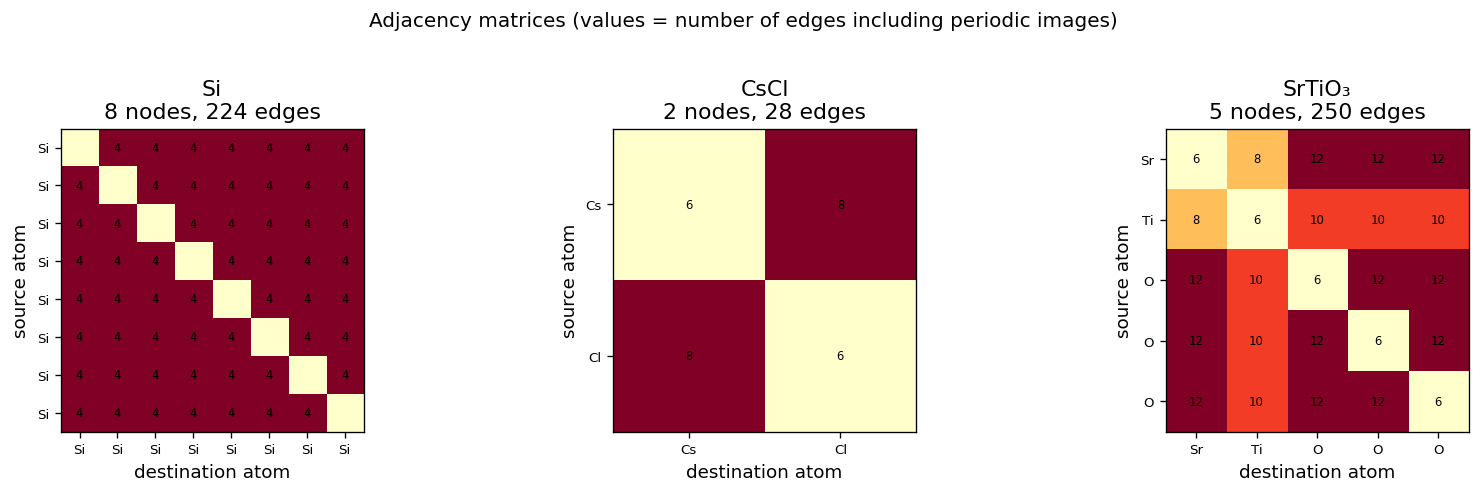

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, struct) in zip(axes, structures.items()):
    g_i, _, _ = converter.get_graph(struct)
    ei = g_i.edge_index.numpy()

    n = g_i.num_nodes
    adj = np.zeros((n, n), dtype=int)
    for src, dst in zip(ei[0], ei[1]):
        adj[src, dst] += 1  # count multiple edges (different periodic images)

    im = ax.imshow(adj, cmap="YlOrRd", interpolation="nearest")
    ax.set_title(f"{name}\n{n} nodes, {ei.shape[1]} edges")
    ax.set_xlabel("destination atom")
    ax.set_ylabel("source atom")

    tick_labels = [f"{struct[i].species_string}" for i in range(n)]
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(tick_labels, fontsize=8)
    ax.set_yticklabels(tick_labels, fontsize=8)

    for i in range(n):
        for j in range(n):
            if adj[i, j] > 0:
                ax.text(j, i, str(adj[i, j]), ha="center", va="center", fontsize=7)

plt.suptitle("Adjacency matrices (values = number of edges including periodic images)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 10. Effect of cutoff radius

The cutoff radius is the most important hyperparameter controlling graph construction. Larger cutoff = more edges = richer information but more expensive computation:

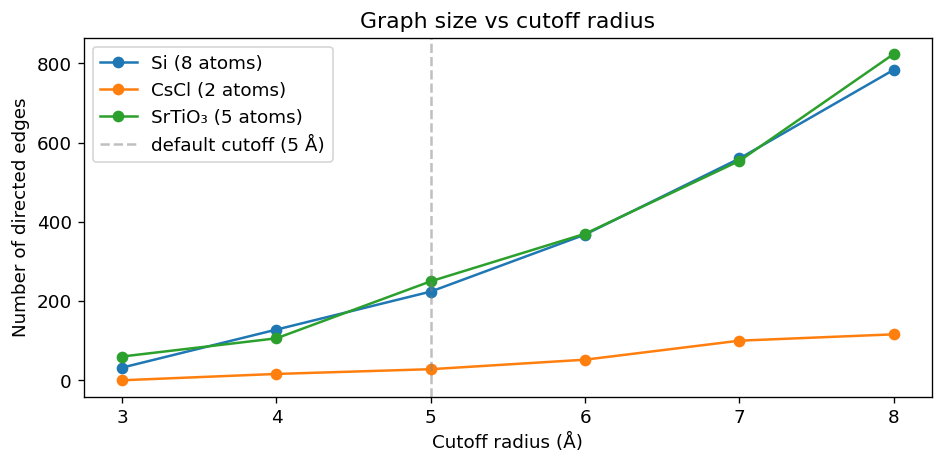

In [11]:
cutoffs = [3.0, 4.0, 5.0, 6.0, 7.0, 8.0]

fig, ax = plt.subplots(figsize=(8, 4))

for name, struct in structures.items():
    edges_per_cutoff = []
    for c in cutoffs:
        conv = Structure2Graph(element_types=element_types, cutoff=c)
        g_c, _, _ = conv.get_graph(struct)
        edges_per_cutoff.append(g_c.edge_index.shape[1])
    ax.plot(cutoffs, edges_per_cutoff, "o-", label=f"{name} ({struct.num_sites} atoms)")

ax.axvline(5.0, color="gray", linestyle="--", alpha=0.5, label="default cutoff (5 Å)")
ax.set_xlabel("Cutoff radius (Å)")
ax.set_ylabel("Number of directed edges")
ax.set_title("Graph size vs cutoff radius")
ax.legend()
plt.tight_layout()
plt.show()

## 11. End-to-end: Structure → Model prediction

Finally, let's run a TensorNet model (untrained, random weights) to see the full pipeline from structure to scalar output. The shapes at each stage show you exactly how data flows:

In [12]:
from matgl.models import TensorNet

model = TensorNet(
    element_types=element_types,
    units=64,
    nblocks=3,
    num_rbf=32,
    cutoff=CUTOFF,
    is_intensive=True,   # prediction is per-formula-unit, not per-atom
    ntargets=1,
)

# Prepare graph for forward pass (same thing the Lightning module does)
g = graph_sto
lat = lattice_sto

num_edges_per_graph = torch.tensor([g.edge_index.shape[1]])
num_nodes_per_graph = torch.tensor([g.num_nodes])

g.pbc_offshift = (g.pbc_offset.unsqueeze(-1) * lat.squeeze(0)).sum(dim=1)
g.pos = (g.frac_coords.unsqueeze(-1) * lat.squeeze(0)).sum(dim=1)
g.batch = torch.zeros(g.num_nodes, dtype=torch.long)
g.num_graphs = 1

with torch.no_grad():
    output = model(g, state_attr=torch.zeros(1, 2))

print("Pipeline trace:")
print(f"  Structure     : SrTiO₃ ({srtio3.num_sites} atoms)")
print(f"  → Graph       : {g.num_nodes} nodes, {g.edge_index.shape[1]} edges")
print(f"  → node_type   : {g.node_type.shape}")
print(f"  → edge_index  : {g.edge_index.shape}")
print(f"  → pos         : {g.pos.shape}")
print(f"  → Model output: {output.shape}  value = {output.item():.4f}")
print(f"\n  (This is random — the model isn't trained yet!)")

Pipeline trace:
  Structure     : SrTiO₃ (5 atoms)
  → Graph       : 5 nodes, 250 edges
  → node_type   : torch.Size([5])
  → edge_index  : torch.Size([2, 250])
  → pos         : torch.Size([5, 3])
  → Model output: torch.Size([])  value = -0.0146

  (This is random — the model isn't trained yet!)


## Summary

| Step | What happens | Key object |
|------|-------------|------------|
| **1. Crystal** | Lattice + atoms + periodicity defines the material | `pymatgen.Structure` |
| **2. Graph** | Atoms → nodes, nearby pairs → edges (with periodic images) | `torch_geometric.data.Data` |
| **3. Node init** | Element type → integer → learned embedding vector | `nn.Embedding` |
| **4. Edge init** | Interatomic distance → RBF expansion → feature vector | `BondExpansion` |
| **5. Message passing** | Each node aggregates neighbour features (N rounds) | `TensorNetInteraction` |
| **6. Readout** | Pool all node features → single graph-level vector | `WeightedAtomReadOut` |
| **7. Prediction** | MLP maps graph vector → scalar (e.g., e_total, band_gap) | `MLP` |

**Next:** In notebook 03, we train this model on real Materials Project data and evaluate how well it predicts a target property from structure alone.